# Logistic Regression, LDA, QDA, and KNN

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/hanchen92/THU-STAT-ML-114-2-1596/blob/main/Ch04-classification-lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/hanchen92/THU-STAT-ML-114-2-1596/blob/main/Ch04-classification-lab.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

## The Diabetes Data

In this lab we will examine the `Diabetes` data set, which contains health indicator variables for predicting diabetes.


In [117]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)

We also collect together the new imports needed for this lab.

In [118]:
from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.discriminant_analysis import \
     (LinearDiscriminantAnalysis as LDA,
      QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt

In [119]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\alan_\.cache\kagglehub\datasets\alexteboul\diabetes-health-indicators-dataset\versions\1


Now we are ready to load the `Diabetes` data.

In [120]:
Health_org = pd.read_csv(path+"\diabetes_binary_5050split_health_indicators_BRFSS2015.csv")
Health = Health_org

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\alan_\AppData\Local\Temp\ipykernel_22640\2920144930.py:1: SyntaxWarning: invalid escape sequence '\d'
  Health_org = pd.read_csv(path+"\diabetes_binary_5050split_health_indicators_BRFSS2015.csv")


This gives a truncated listing of the data.
We can see what the variable names are.

In [121]:
Health.columns

Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [122]:
Health.shape

(70692, 22)

We compute the correlation matrix using the `corr()` method
for data frames, which produces a matrix that contains all of
the pairwise correlations among the variables.
 
By instructing `pandas` to use only numeric variables, we get a pairwise correlation summary among all numeric health indicators.


In [123]:
Health.corr(numeric_only=True)

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
Diabetes_binary,1.000000,0.381516,0.289213,0.115382,0.293373,0.085999,0.125427,0.211523,-0.158666,-0.054077,...,0.023191,0.040977,0.407612,0.087029,0.213081,0.272646,0.044413,0.278738,-0.170481,-0.224449
HighBP,0.381516,1.000000,0.316515,0.103283,0.241019,0.087438,0.129060,0.210750,-0.136102,-0.040852,...,0.035764,0.026517,0.320540,0.064294,0.173922,0.234784,0.040819,0.338132,-0.141643,-0.187657
HighChol,0.289213,0.316515,1.000000,0.085981,0.131309,0.093398,0.099786,0.181187,-0.090453,-0.047384,...,0.031532,0.033199,0.237778,0.083881,0.142610,0.162043,0.017324,0.240338,-0.084386,-0.107777
CholCheck,0.115382,0.103283,0.085981,1.000000,0.045648,-0.004331,0.022529,0.043497,-0.008249,0.017384,...,0.106800,-0.062669,0.059213,-0.010660,0.034540,0.044430,-0.007991,0.101743,-0.008695,0.007550
BMI,0.293373,0.241019,0.131309,0.045648,1.000000,0.011551,0.022931,0.060355,-0.170936,-0.084505,...,-0.013417,0.065832,0.267888,0.104682,0.161862,0.246094,0.000827,-0.038648,-0.100233,-0.124878
Smoker,0.085999,0.087438,0.093398,-0.004331,0.011551,1.000000,0.064658,0.124418,-0.079823,-0.074811,...,-0.012939,0.035799,0.152416,0.091257,0.120698,0.119789,0.112125,0.105424,-0.140966,-0.104725
Stroke,0.125427,0.129060,0.099786,0.022529,0.022931,0.064658,1.000000,0.223394,-0.079985,-0.008996,...,0.006484,0.036198,0.189447,0.087303,0.164488,0.192266,0.003822,0.123879,-0.073926,-0.136577
HeartDiseaseorAttack,0.211523,0.210750,0.181187,0.043497,0.060355,0.124418,0.223394,1.000000,-0.098223,-0.019436,...,0.015687,0.036029,0.275868,0.075057,0.198416,0.232611,0.098161,0.221878,-0.096559,-0.146748
PhysActivity,-0.158666,-0.136102,-0.090453,-0.008249,-0.170936,-0.079823,-0.079985,-0.098223,1.000000,0.133813,...,0.027089,-0.063302,-0.273548,-0.130090,-0.234500,-0.276868,0.051753,-0.100753,0.190271,0.196551
Fruits,-0.054077,-0.040852,-0.047384,0.017384,-0.084505,-0.074811,-0.008996,-0.019436,0.133813,1.000000,...,0.029385,-0.045843,-0.098687,-0.062102,-0.048572,-0.050784,-0.088723,0.061096,0.098715,0.079009


## Logistic Regression
Next, we will fit a logistic regression model in order to predict
 `Diabetes_binary` using all other variables. The `sm.GLM()`  function fits *generalized linear models*, a class of
models that includes logistic regression.  Alternatively,
the function `sm.Logit()` fits a logistic regression
model directly. The syntax of
`sm.GLM()` is similar to that of `sm.OLS()`, except
that we must pass in the argument `family=sm.families.Binomial()`
in order to tell `statsmodels` to run a logistic regression rather than some other
type of generalized linear model.


In [124]:
all_cat_vars = ["GenHlth","Age","Education","Income"]

for tmp_var in all_cat_vars:
    Health[tmp_var] = pd.Series(Health[tmp_var], dtype='category')


In [125]:
allvars = Health.columns.drop(['Diabetes_binary'])
design = MS(allvars)
X = design.fit_transform(Health)
y = Health.Diabetes_binary 
glm = sm.GLM(y,
             X,
             family=sm.families.Binomial())
results = glm.fit()
summarize(results)


,coef,std err,z,P>|z|
intercept,-7.0445,0.322,-21.900,0.000
HighBP,0.7115,0.020,35.878,0.000
HighChol,0.5516,0.019,28.997,0.000
CholCheck,1.3527,0.081,16.667,0.000
BMI,0.0715,0.002,45.216,0.000
Smoker,-0.0250,0.019,-1.311,0.190
Stroke,0.1887,0.041,4.626,0.000
HeartDiseaseorAttack,0.2877,0.028,10.099,0.000
PhysActivity,-0.0370,0.021,-1.733,0.083
Fruits,-0.0161,0.020,-0.815,0.415


We use the `params`  attribute of `results`
in order to access just the
coefficients for this fitted model.

In [126]:
results.params

intercept              -7.044477
HighBP                  0.711506
HighChol                0.551644
CholCheck               1.352684
BMI                     0.071476
Smoker                 -0.024997
Stroke                  0.188748
HeartDiseaseorAttack    0.287668
PhysActivity           -0.036988
Fruits                 -0.016063
Veggies                -0.055599
HvyAlcoholConsump      -0.753397
AnyHealthcare           0.061223
NoDocbcCost             0.012116
GenHlth[2.0]            0.728856
GenHlth[3.0]            1.440785
GenHlth[4.0]            1.897310
GenHlth[5.0]            2.034665
MentHlth               -0.003287
PhysHlth               -0.004053
DiffWalk                0.146501
Sex                     0.278619
Age[2.0]                0.022715
Age[3.0]                0.381074
Age[4.0]                0.703735
Age[5.0]                0.974009
Age[6.0]                1.200442
Age[7.0]                1.423789
Age[8.0]                1.495465
Age[9.0]                1.737553
Age[10.0] 

Likewise we can use the
`pvalues`  attribute to access the *p*-values for the coefficients.

In [127]:
results.pvalues

intercept               2.579042e-106
HighBP                  6.678487e-282
HighChol                7.216880e-185
CholCheck                2.288410e-62
BMI                      0.000000e+00
Smoker                   1.898641e-01
Stroke                   3.720041e-06
HeartDiseaseorAttack     5.578131e-24
PhysActivity             8.310277e-02
Fruits                   4.151507e-01
Veggies                  1.757059e-02
HvyAlcoholConsump        1.566631e-53
AnyHealthcare            1.972131e-01
NoDocbcCost              7.231621e-01
GenHlth[2.0]             4.164975e-80
GenHlth[3.0]             0.000000e+00
GenHlth[4.0]             0.000000e+00
GenHlth[5.0]            3.415292e-272
MentHlth                 1.061579e-02
PhysHlth                 1.062669e-03
DiffWalk                 1.695595e-08
Sex                      3.066714e-47
Age[2.0]                 8.876407e-01
Age[3.0]                 8.351044e-03
Age[4.0]                 2.884096e-07
Age[5.0]                 3.647539e-13
Age[6.0]    

The `predict()` method of `results` can be used to predict the
probability that a person has diabetes, given values of the
predictors. This method returns predictions
on the probability scale. If no data set is supplied to the `predict()`
function, then the probabilities are computed for the training data
that was used to fit the logistic regression model.
As with linear regression, one can pass an optional `exog` argument consistent
with a design matrix if desired. Here we have
printed only the first ten probabilities.


In [128]:
probs = results.predict()
probs[:10]

array([0.23732548, 0.7335602 , 0.11021006, 0.71781968, 0.1596735 ,
       0.0202163 , 0.12167105, 0.50412266, 0.12681984, 0.3151719 ])

In order to make a prediction as to whether a person has diabetes or
not, we must convert these predicted
probabilities into class labels, `0` (no diabetes) or `1` (diabetes). The
following two commands create a vector of class predictions based on
whether the predicted probability of diabetes is greater than
or less than 0.5.


In [129]:
labels = np.array([0]*Health.shape[0])
labels[probs>0.5] = 1

In [130]:
labels

array([0, 1, 0, ..., 1, 1, 1])

In [131]:
np.unique(labels)

array([0, 1])

The `confusion_table()`
function from the `ISLP` package summarizes these predictions, showing how
many observations were correctly or incorrectly classified. Our function, which is adapted from a similar function
in the module `sklearn.metrics`, transposes the resulting
matrix and includes row and column labels.
The `confusion_table()` function takes as first argument the
predicted labels, and second argument the true labels.


In [132]:
Health.shape[0]

70692

In [133]:
confusion_table(labels, Health.Diabetes_binary)

Truth,0.0,1.0
Predicted,,
0.0,25546,7906
1.0,9800,27440


The diagonal elements of the confusion matrix indicate correct
predictions, while the off-diagonals represent incorrect
predictions. Hence our model correctly predicted the diabetes status
for the observations on the diagonal. The `np.mean()`
function can be used to compute the fraction of observations for which the
prediction was correct.


In [134]:
(25431+27487)/70692, np.mean(labels == Health.Diabetes_binary)

(0.7485712669043173, 0.7495331862162621)

At first glance, it appears that the logistic regression model is
working reasonably well. However, this result is
misleading because we trained and tested the model on the same set of
observations. In other words, this is the
*training* error rate. As we have seen
previously, the training error rate is often overly optimistic --- it
tends to underestimate the test error rate. In
order to better assess the accuracy of the logistic regression model
in this setting, we can fit the model using part of the data, and
then examine how well it predicts the *held out* data. This
will yield a more realistic error rate, in the sense that in practice
we will be interested in our model's performance not on the data that
we used to fit the model, but rather on new, unseen observations.

To implement this strategy, we split the data into a training set (70%) and a test set (30%) using `train_test_split()`.


In [135]:
(X_train,
 X_test,
 y_train,
 y_test) = train_test_split(np.asarray(X),
                            y,
                            test_size=0.3,
                            random_state=0)

We use `train_test_split()` with `test_size=0.3` and `random_state=0` to get a reproducible 70/30 split of the data into training and test sets.

We now fit a logistic regression model using only the training observations, and then obtain predicted probabilities for each observation in the test set.


In [136]:
glm_train = sm.GLM(y_train,
                   X_train,
                   family=sm.families.Binomial())
results = glm_train.fit()
probs = results.predict(exog=X_test)


Notice that we have trained and tested our model on two completely
separate data sets: the model was fitted using only the training observations,
and evaluation was performed on the held-out test observations.

We will first visualize the distribution of predicted probabilities grouped by the true label (0 = no diabetes, 1 = diabetes).


<Axes: title={'center': 'probs'}, xlabel='labels'>

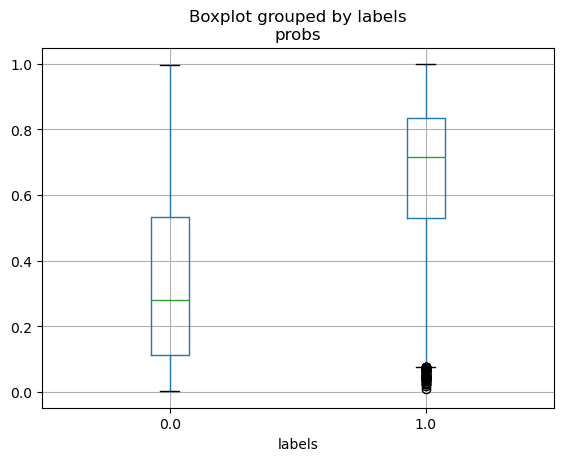

In [137]:
pd.DataFrame({'probs': probs,'labels': y_test}).boxplot('probs',by='labels')

Now we threshold the
fitted probability at 50% to form
our predicted labels.


In [138]:
labels = np.array([0]*len(y_test))
labels[probs>0.5] = 1
confusion_table(labels, y_test)


Truth,0.0,1.0
Predicted,,
0.0,7555,2342
1.0,2926,8385


The results above show the confusion matrix for the test set. We can compute accuracy and error rate below.


In [139]:
np.mean(labels == y_test), np.mean(labels != y_test)


(0.7516031686156167, 0.24839683138438326)

The `!=` notation means *not equal to*, and so the last command
computes the test set error rate. The results show whether the logistic regression model generalizes well to unseen data. A higher test accuracy suggests the model captures genuine patterns in the health indicators.


## Linear Discriminant Analysis

We begin by performing LDA on the `Diabetes` data, using the function
`LinearDiscriminantAnalysis()`, which we have abbreviated `LDA()`. We
fit the model using only the training observations.


In [140]:
lda = LDA(store_covariance=True)

Since the `LDA` estimator automatically 
adds an intercept, we should remove the column corresponding to the
intercept in both `X_train` and `X_test`. We can also directly
use the labels rather than the Boolean vectors `y_train`.

In [141]:
X_train, X_test = [M[:,1:]
                   for M in [X_train, X_test]]
lda.fit(X_train, y_train)


LinearDiscriminantAnalysis(store_covariance=True)

Here we have used list comprehensions to simultaneously drop the intercept column from both `X_train` and `X_test`, since `LDA` adds an intercept automatically.

Having fit the model, we can extract the means in the two classes with the `means_` attribute. These are the average of each predictor within each class, and
are used by LDA as estimates of $\mu_k$. These suggest differences in average feature values between the diabetic and non-diabetic groups.


In [142]:
lda.means_


array([[3.75025136e-01, 3.82666399e-01, 9.57329580e-01, 2.77239493e+01,
        4.34908506e-01, 3.20933038e-02, 7.23909109e-02, 7.76432737e-01,
        6.39292178e-01, 8.20309672e-01, 6.38246531e-02, 9.51779610e-01,
        8.14799920e-02, 3.81379449e-01, 2.82083250e-01, 9.77277297e-02,
        3.49487231e-02, 3.02831289e+00, 3.66945506e+00, 1.33923185e-01,
        4.37442188e-01, 3.57932837e-02, 4.95877740e-02, 6.10898854e-02,
        7.02996179e-02, 8.23647698e-02, 1.04926604e-01, 1.22823246e-01,
        1.23909109e-01, 1.21335210e-01, 8.38528051e-02, 5.58616529e-02,
        6.22159662e-02, 1.36738387e-02, 3.23346069e-02, 2.38849789e-01,
        2.73235472e-01, 4.41262819e-01, 4.06997788e-02, 5.69877338e-02,
        7.34767746e-02, 9.87733762e-02, 1.41162276e-01, 1.74622964e-01,
        3.79891414e-01],
       [7.50761607e-01, 6.68914253e-01, 9.93094764e-01, 3.19436614e+01,
        5.15414923e-01, 9.09053983e-02, 2.19586498e-01, 6.32113408e-01,
        5.88529185e-01, 7.57423128e-01,

The estimated prior probabilities are stored in the `priors_` attribute.
The package `sklearn` typically uses this trailing `_` to denote
a quantity estimated when using the `fit()` method. We can be sure of which
entry corresponds to which label by looking at the `classes_` attribute.

In [143]:
lda.classes_


array([0., 1.])

The LDA output indicates the estimated prior probabilities $\hat{\pi}_0$ and $\hat{\pi}_1$ for the two classes (no diabetes and diabetes).


In [144]:
lda.priors_


array([0.50248565, 0.49751435])

The linear discriminant vectors can be found in the `scalings_` attribute:

In [145]:
lda.scalings_


array([[ 6.35168257e-01],
       [ 4.44994347e-01],
       [ 6.98894032e-01],
       [ 4.98031698e-02],
       [-3.21260016e-02],
       [ 1.25471002e-01],
       [ 2.22923956e-01],
       [-3.90842273e-02],
       [-1.16202278e-02],
       [-3.64916484e-02],
       [-5.49854678e-01],
       [ 1.10859382e-02],
       [-7.16223597e-05],
       [ 3.69539335e-01],
       [ 1.02340370e+00],
       [ 1.40882472e+00],
       [ 1.45537180e+00],
       [-2.47155775e-03],
       [-3.50803794e-03],
       [ 1.38719196e-01],
       [ 1.87381287e-01],
       [ 1.04386238e-02],
       [ 1.13129700e-01],
       [ 2.51936553e-01],
       [ 4.03469149e-01],
       [ 5.14228252e-01],
       [ 7.00942528e-01],
       [ 7.35200570e-01],
       [ 9.34442263e-01],
       [ 1.06221988e+00],
       [ 1.16626164e+00],
       [ 1.12908602e+00],
       [ 1.05163199e+00],
       [ 8.17661138e-02],
       [ 7.44584418e-02],
       [ 7.30631663e-03],
       [ 2.96282941e-02],
       [-5.33626350e-02],
       [ 1.2

These values provide the linear combination of the health indicator features that are used to form the LDA decision rule. In other words, these are the multipliers of the elements of $X=x$ in the LDA classifier. A large value of this linear combination predicts diabetes (class 1), while a small value predicts no diabetes (class 0).


In [146]:
lda_pred = lda.predict(X_test)


As we observed in our comparison of classification methods, the LDA and logistic
regression predictions are often similar when the class-conditional distributions are approximately Gaussian.


In [147]:
confusion_table(lda_pred, y_test)


Truth,0.0,1.0
Predicted,,
0.0,7488,2261
1.0,2993,8466


In [148]:
np.mean(lda_pred == y_test)

0.752263296869106

We can also estimate the
probability of each class for
each point in the test set. Applying a 50% threshold to the posterior probabilities of
being in class 1 (diabetes) allows us to
recreate the predictions contained in `lda_pred`.


In [149]:
lda_prob = lda.predict_proba(X_test)
np.all(
       np.where(lda_prob[:,1] >= 0.5, 1, 0) == lda_pred
       )


True

Above, we used the `np.where()` function that
creates an array with value `1` for indices where
the second column of `lda_prob` (the estimated
posterior probability of having diabetes) is greater than or equal to 0.5.
For problems with more than two classes the labels are chosen as the class whose posterior probability is highest:


In [150]:
np.all(
       [lda.classes_[i] for i in np.argmax(lda_prob, 1)] == lda_pred
       )


True

## Quadratic Discriminant Analysis
We will now fit a QDA model to the `Diabetes` data. QDA is
implemented via
`QuadraticDiscriminantAnalysis()`
in the `sklearn` package, which we abbreviate to `QDA()`.
The syntax is very similar to `LDA()`.


In [151]:
qda = QDA(store_covariance=True)
qda.fit(X_train, y_train)


QuadraticDiscriminantAnalysis(store_covariance=True)

The `QDA()` function will again compute `means_` and `priors_`.

In [152]:
qda.means_, qda.priors_


(array([[3.75025136e-01, 3.82666399e-01, 9.57329580e-01, 2.77239493e+01,
         4.34908506e-01, 3.20933038e-02, 7.23909109e-02, 7.76432737e-01,
         6.39292178e-01, 8.20309672e-01, 6.38246531e-02, 9.51779610e-01,
         8.14799920e-02, 3.81379449e-01, 2.82083250e-01, 9.77277297e-02,
         3.49487231e-02, 3.02831289e+00, 3.66945506e+00, 1.33923185e-01,
         4.37442188e-01, 3.57932837e-02, 4.95877740e-02, 6.10898854e-02,
         7.02996179e-02, 8.23647698e-02, 1.04926604e-01, 1.22823246e-01,
         1.23909109e-01, 1.21335210e-01, 8.38528051e-02, 5.58616529e-02,
         6.22159662e-02, 1.36738387e-02, 3.23346069e-02, 2.38849789e-01,
         2.73235472e-01, 4.41262819e-01, 4.06997788e-02, 5.69877338e-02,
         7.34767746e-02, 9.87733762e-02, 1.41162276e-01, 1.74622964e-01,
         3.79891414e-01],
        [7.50761607e-01, 6.68914253e-01, 9.93094764e-01, 3.19436614e+01,
         5.15414923e-01, 9.09053983e-02, 2.19586498e-01, 6.32113408e-01,
         5.88529185e-01, 

The `QDA()` classifier will estimate one covariance per class. Here is the
estimated covariance in the first class:

In [153]:
qda.covariance_[0]


array([[ 2.34390710e-01,  6.21233846e-02,  7.75827176e-03, ...,
         5.13440209e-03, -2.46779035e-03, -2.86553826e-02],
       [ 6.21233846e-02,  2.36242327e-01,  7.23974617e-03, ...,
         3.38216330e-05,  1.82844665e-03, -1.15696107e-02],
       [ 7.75827176e-03,  7.23974617e-03,  4.08512984e-02, ...,
         5.13721652e-04,  4.93684235e-04,  2.37551439e-03],
       ...,
       [ 5.13440209e-03,  3.38216330e-05,  5.13721652e-04, ...,
         1.21240364e-01, -2.46511665e-02, -5.36284935e-02],
       [-2.46779035e-03,  1.82844665e-03,  4.93684235e-04, ...,
        -2.46511665e-02,  1.44135581e-01, -6.63404327e-02],
       [-2.86553826e-02, -1.15696107e-02,  2.37551439e-03, ...,
        -5.36284935e-02, -6.63404327e-02,  2.35583402e-01]])

The output contains the group means. But it does not contain the
coefficients of the linear discriminants, because the QDA classifier
involves a quadratic, rather than a linear, function of the
predictors. The `predict()`  function works in exactly the
same fashion as for LDA.

In [154]:
qda_pred = qda.predict(X_test)
confusion_table(qda_pred, y_test)


Truth,0.0,1.0
Predicted,,
0.0,6055,1535
1.0,4426,9192


We can evaluate how well the QDA predictions perform on the test set by computing accuracy.


In [155]:
np.mean(qda_pred == y_test)


0.7189268200678989

This suggests whether the
quadratic form assumed by QDA captures the true relationship more
accurately than the linear forms assumed by LDA and logistic
regression. However, we recommend evaluating each method's
performance carefully before drawing strong conclusions about which approach works best on this dataset.


## Naive Bayes
Next, we fit a naive Bayes model to the `Diabetes` data. The syntax is
similar to that of `LDA()` and `QDA()`. By
default, this implementation `GaussianNB()` of the naive Bayes classifier models each
quantitative feature using a Gaussian distribution. However, a kernel
density method can also be used to estimate the distributions.


In [156]:
NB = GaussianNB()
NB.fit(X_train, y_train)


GaussianNB()

The classes are stored as `classes_`.

In [157]:
NB.classes_


array([0., 1.])

The class prior probabilities are stored in the `class_prior_` attribute.

In [158]:
NB.class_prior_


array([0.50248565, 0.49751435])

The parameters of the features can be found in the `theta_` and `var_` attributes. The number of rows
is equal to the number of classes, while the number of columns is equal to the number of features.
Each entry gives the estimated mean for a given feature within a given class.


In [159]:
NB.theta_


array([[3.75025136e-01, 3.82666399e-01, 9.57329580e-01, 2.77239493e+01,
        4.34908506e-01, 3.20933038e-02, 7.23909109e-02, 7.76432737e-01,
        6.39292178e-01, 8.20309672e-01, 6.38246531e-02, 9.51779610e-01,
        8.14799920e-02, 3.81379449e-01, 2.82083250e-01, 9.77277297e-02,
        3.49487231e-02, 3.02831289e+00, 3.66945506e+00, 1.33923185e-01,
        4.37442188e-01, 3.57932837e-02, 4.95877740e-02, 6.10898854e-02,
        7.02996179e-02, 8.23647698e-02, 1.04926604e-01, 1.22823246e-01,
        1.23909109e-01, 1.21335210e-01, 8.38528051e-02, 5.58616529e-02,
        6.22159662e-02, 1.36738387e-02, 3.23346069e-02, 2.38849789e-01,
        2.73235472e-01, 4.41262819e-01, 4.06997788e-02, 5.69877338e-02,
        7.34767746e-02, 9.87733762e-02, 1.41162276e-01, 1.74622964e-01,
        3.79891414e-01],
       [7.50761607e-01, 6.68914253e-01, 9.93094764e-01, 3.19436614e+01,
        5.15414923e-01, 9.09053983e-02, 2.19586498e-01, 6.32113408e-01,
        5.88529185e-01, 7.57423128e-01,

The `var_` attribute stores the estimated variance for each feature within each class.


In [160]:
NB.var_


array([[2.34381384e-01, 2.36232927e-01, 4.08497561e-02, 3.80857105e+01,
        2.45763198e-01, 3.10634243e-02, 6.71505675e-02, 1.73585043e-01,
        2.30597790e-01, 1.47401814e-01, 5.97511674e-02, 4.58952847e-02,
        7.48411035e-02, 2.35929265e-01, 2.02512390e-01, 8.81771212e-02,
        3.37274105e-02, 5.16682916e+01, 6.57694049e+01, 1.15987866e-01,
        2.46086621e-01, 3.45122252e-02, 4.71289273e-02, 5.73580119e-02,
        6.53576823e-02, 7.55809151e-02, 9.39171121e-02, 1.07737796e-01,
        1.08555742e-01, 1.06613078e-01, 7.68216128e-02, 5.27412293e-02,
        5.83452404e-02, 1.34869655e-02, 3.12891807e-02, 1.81800668e-01,
        1.98577949e-01, 2.46550044e-01, 3.90434074e-02, 5.37402326e-02,
        6.80780388e-02, 8.90172970e-02, 1.21235589e-01, 1.44129885e-01,
        2.35574028e-01],
       [1.87118717e-01, 2.21468076e-01, 6.85765411e-03, 5.34785678e+01,
        2.49762481e-01, 8.26417074e-02, 1.71368369e-01, 2.32546148e-01,
        2.42162684e-01, 1.83733434e-01,

How do we know the names of these attributes? We use `NB?` (or `?NB`).

We can easily verify the mean computation:

In [161]:
X_train[y_train == 0].mean()


0.9847952275621691

Similarly for the variance:

In [162]:
X_train[y_train == 0].var(ddof=0)


20.289521032425327

Since `NB()` is a classifier in the `sklearn` library, making predictions
uses the same syntax as for `LDA()` and `QDA()` above.

In [163]:
nb_labels = NB.predict(X_test)
confusion_table(nb_labels, y_test)


Truth,0.0,1.0
Predicted,,
0.0,6922,2405
1.0,3559,8322


The confusion matrix above shows the Naive Bayes classifier's predictions on the test set. We can compute the overall accuracy below.

As for `LDA`, the `predict_proba()` method estimates the probability that each observation belongs to a particular class.


In [164]:
NB.predict_proba(X_test)[:5]


array([[2.47391579e-06, 9.99997526e-01],
       [6.40781077e-01, 3.59218923e-01],
       [9.99998357e-01, 1.64324524e-06],
       [1.71807679e-05, 9.99982819e-01],
       [1.49935358e-02, 9.85006464e-01]])

In [165]:
np.mean(nb_labels==y_test)

0.7187853640135797

## K-Nearest Neighbors
We will now perform KNN using the `KNeighborsClassifier()` function. This function works similarly
to the other model-fitting functions that we have
encountered thus far.

As is the
case for LDA and QDA, we fit the classifier
using the `fit` method. New
predictions are formed using the `predict` method
of the object returned by `fit()`.

In [166]:
knn1 = KNeighborsClassifier(n_neighbors=1)
X_train, X_test = [np.asarray(X) for X in [X_train, X_test]]
knn1.fit(X_train, y_train)
knn1_pred = knn1.predict(X_test)
confusion_table(knn1_pred, y_test)


Truth,0.0,1.0
Predicted,,
0.0,6883,3781
1.0,3598,6946


The results using $K=1$ show how well the nearest-neighbor classifier performs on the test data. With $K=1$, the decision boundary is very flexible, which may lead to overfitting.


In [167]:
np.mean(knn1_pred == y_test)


0.6520652583930592

We repeat the
analysis below using $K=3$.

In [168]:
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3_pred = knn3.fit(X_train, y_train).predict(X_test)
np.mean(knn3_pred == y_test)

0.6821482459449264

The results may improve with a larger $K$. However, increasing $K$ further may not always help. It appears that for these data and this train/test split, we should compare all methods to determine which gives the best generalization performance.


Because the KNN classifier predicts the class of a given test
observation by identifying the observations that are nearest to it,
the scale of the variables matters. Any variables that are on a large
scale will have a much larger effect on the *distance* between
the observations, and hence on the KNN classifier, than variables that
are on a small scale. For instance, imagine a data set that contains
two variables,  `salary`  and  `age`  (measured in dollars
and years, respectively). As far as KNN is concerned, a difference of
1,000 USD in salary is enormous compared to a difference of 50 years in
age. Consequently,  `salary`  will drive the KNN classification
results, and  `age`  will have almost no effect. This is contrary
to our intuition that a salary difference of 1,000 USD is quite small
compared to an age difference of 50 years.  Furthermore, the
importance of scale to the KNN classifier leads to another issue: if
we measured  `salary`  in Japanese yen, or if we measured
 `age`  in minutes, then we’d get quite different classification
results from what we get if these two variables are measured in
dollars and years.

A good way to handle this problem is to *standardize*  the data so that all variables are
given a mean of zero and a standard deviation of one. Then all
variables will be on a comparable scale. This is accomplished
using
the `StandardScaler()`
transformation.

In [169]:
scaler = StandardScaler(with_mean=True,
                        with_std=True,
                        copy=True)


The argument `with_mean` indicates whether or not
we should subtract the mean, while `with_std` indicates
whether or not we should scale the columns to have standard
deviation of 1 or not. Finally, the argument `copy=True`
indicates that we will always copy data, rather than
trying to do calculations in place where possible.

This transformation can be fit
and then applied to arbitrary data. In the first line
below, the parameters for the scaling are computed and
stored in `scaler`, while the second line actually
constructs the standardized set of features.

In [170]:
X2 = X.drop("intercept", axis = 1)
scaler.fit(X2)
X_std = scaler.transform(X2)


Notice that the standard deviations are not quite $1$ here; this is again due to some procedures using the $1/n$ convention for variances (in this case `scaler()`), while others use $1/(n-1)$ (the `std()` method). See the footnote on page~\pageref{Ch4-varformula}.
In this case it does not matter, as long as the variables are all on the same scale.

Using the function `train_test_split()`  we now split the observations into a test set,
containing 1000 observations, and a training set containing the remaining
observations. The argument `random_state=0` ensures that we get
the same split each time we rerun the code.

In [171]:
(X_train,
 X_test,
 y_train,
 y_test) = train_test_split(np.asarray(X_std),
                            y,
                            test_size=0.3,
                            random_state=0)


`?train_test_split` reveals that the non-keyword arguments can be `lists`, `arrays`, `pandas dataframes` etc that all have the same length (`shape[0]`) and hence are *indexable*. In this case they are the standardized feature array and the response variable `Diabetes_binary`.
Note that we have converted the features to an `ndarray` to address a bug in `sklearn`.

We fit a KNN model on the training data using $K=1$,
and evaluate its performance on the test data.


In [172]:
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1_pred = knn1.fit(X_train, y_train).predict(X_test)
np.mean(knn1_pred == y_test)


0.6528196906827612

After standardizing the features, we refit KNN. The overall test accuracy gives one view of performance, but it is also worth examining what fraction of positive predictions (predicted diabetic) are truly diabetic — i.e., the precision — to understand practical usefulness.


In [173]:
confusion_table(knn1_pred, y_test)


Truth,0.0,1.0
Predicted,,
0.0,6868,3750
1.0,3613,6977


The confusion table above shows the detailed breakdown of KNN predictions. We can loop over multiple values of $K$ to find the best-performing model on the test data.


### Tuning Parameters

The number of neighbors in KNN is referred to as a *tuning parameter*, also referred to as a *hyperparameter*.
We do not know *a priori* what value to use. It is therefore of interest
to see how the classifier performs on test data as we vary these
parameters. This can be achieved with a `for` loop.
Here we use a for loop to look at the accuracy of our classifier
as we vary the number of neighbors from 1 to 51:


In [175]:
for K in range(1,101,5):
    knn = KNeighborsClassifier(n_neighbors=K)
    knn_pred = knn.fit(X_train, y_train).predict(X_test)
    tmp_acc = np.mean(knn_pred==y_test)
    print(K,tmp_acc)


1 0.6528196906827612
6 0.6933232742361373
11 0.7194926442851755
16 0.7246793662768767
21 0.728498679743493
26 0.7281686156167484
31 0.7319879290833647
36 0.7295360241418333
41 0.7323651452282157
46 0.7329309694454923
51 0.7341097698981517
56 0.7332610335722369
61 0.7336382497170879
66 0.7331667295360241
71 0.7353357223689174
76 0.7351471142964919
81 0.7350999622783855
86 0.7350999622783855
91 0.7351471142964919
96 0.73491135420596
